# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# Import pustaka yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
#Memuat file dataset dalam daraframe
test = pd.read_csv("/content/hasil_melakukan_clustering.csv")
test.head()

,age,sex,bmi,children,smoker,region,charges,age_binned,bmi_binned,Cluster
0,-1.440418,0,-0.453160,-0.909234,1,3,0.297857,0,NaN,0
1,-1.511647,1,0.509422,-0.079442,0,2,-0.954381,0,Underweight,7
2,-0.799350,1,0.383155,1.580143,0,2,-0.729373,1,Underweight,4
3,-0.443201,1,-1.305052,-0.909234,0,1,0.719104,1,NaN,0
4,-0.514431,1,-0.292456,-0.909234,0,1,-0.777499,1,NaN,3


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [3]:
# Pisahkan fitur (X) dan label (y)
X = test.drop(columns=['Cluster'])  # 'Cluster' adalah label hasil clustering
y = test['Cluster']

# Memisahkan data menjadi training set (80%) dan test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verifikasi bentuk data
print("Data Training:")
print(f"Fitur: {X_train.shape}, Label: {y_train.shape}")
print("\nData Testing:")
print(f"Fitur: {X_test.shape}, Label: {y_test.shape}")

Data Training:
Fitur: (953, 9), Label: (953,)

Data Testing:
Fitur: (239, 9), Label: (239,)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [4]:
# Langkah 1: Verifikasi Tipe Data
print("Tipe data di X_train sebelum encoding:")
print(X_train.dtypes)

print("\nTipe data di y_train sebelum encoding:")
print(y_train.dtypes)

# Langkah 2: Encoding Data Kategorikal di X_train dan X_test
categorical_cols = X_train.select_dtypes(include=['object']).columns  # Identifikasi kolom kategorikal
encoder = LabelEncoder()

for col in categorical_cols:
    X_train[col] = encoder.fit_transform(X_train[col])  # Encoding data latih
    X_test[col] = encoder.transform(X_test[col])  # Encoding data uji

# Encoding y_train dan y_test jika perlu
if y_train.dtypes == 'object' or y_train.dtypes == 'category':
    y_train = encoder.fit_transform(y_train)
    y_test = encoder.transform(y_test)

print("\nTipe data di X_train setelah encoding:")
print(X_train.dtypes)

# Langkah 3: Latih Model
model = RandomForestClassifier(random_state=42)

# Melatih model
model.fit(X_train, y_train)

# Evaluasi model
y_pred = model.predict(X_test)
print("\nAkurasi Model pada Data Uji:")
print(accuracy_score(y_test, y_pred))

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Tipe data di X_train sebelum encoding:
age           float64
sex             int64
bmi           float64
children      float64
smoker          int64
region          int64
charges       float64
age_binned      int64
bmi_binned     object
dtype: object

Tipe data di y_train sebelum encoding:
int64

Tipe data di X_train setelah encoding:
age           float64
sex             int64
bmi           float64
children      float64
smoker          int64
region          int64
charges       float64
age_binned      int64
bmi_binned      int64
dtype: object

Akurasi Model pada Data Uji:
0.9372384937238494

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.95      0.90      0.93        21
           2       1.00      0.92      0.96        24
           3       1.00      1.00      1.00        35
           4       0.82      0.93      0.88        15
           5       0.86      0.86      0.86        21
 

- Random Forest adalah salah satu algoritma pembelajaran mesin berbasis ensemble yang terdiri dari banyak pohon keputusan (decision trees). Algoritma ini bekerja dengan cara membangun banyak pohon keputusan selama pelatihan, kemudian mengambil hasil prediksi berdasarkan rata-rata (untuk regresi) atau voting mayoritas (untuk klasifikasi).
- Preprocessing Data
  - Memeriksa tipe data untuk mengenali fitur yang bersifat kategorikal.
  - Menerapkan Label Encoding untuk mengubah nilai kategori menjadi bentuk numerik.
  - Jika kategori dalam suatu fitur cukup banyak, One-Hot Encoding digunakan agar model tidak salah mengartikan urutan angka.
  - Menyelaraskan fitur dengan (`align()`) agar (`X_train`) dan (`X_test`) memiliki jumlah kolom yang sama, sehingga model dapat memproses input tanpa kendala.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

Akurasi: 0.94
F1-Score: 0.94
Precision: 0.94
Recall: 0.94

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.95      0.90      0.93        21
           2       1.00      0.92      0.96        24
           3       1.00      1.00      1.00        35
           4       0.82      0.93      0.88        15
           5       0.86      0.86      0.86        21
           6       0.88      0.95      0.91        37
           7       0.96      0.96      0.96        26
           8       0.96      0.90      0.93        29
           9       0.94      1.00      0.97        17

    accuracy                           0.94       239
   macro avg       0.94      0.93      0.93       239
weighted avg       0.94      0.94      0.94       239



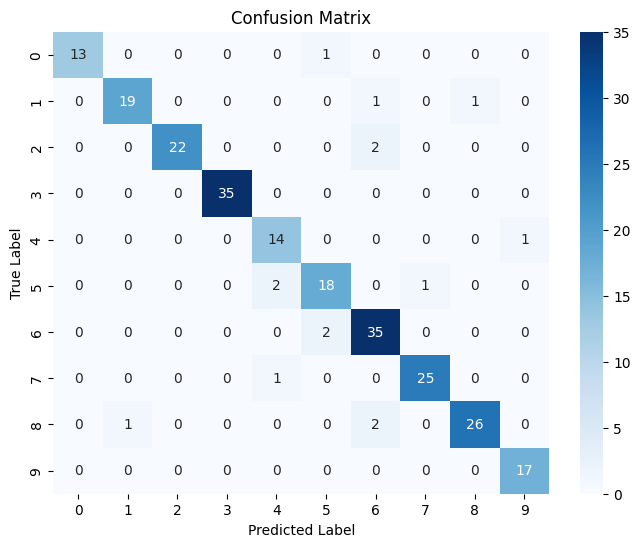

In [5]:
# Langkah 1: Prediksi Data Uji
y_pred = model.predict(X_test)

# Langkah 2: Hitung Metrik Evaluasi
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Akurasi: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# Langkah 3: Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## **Evaluasi Random Forest Classifier**
Random Forest adalah algoritma berbasis ensemble yang menggabungkan banyak Decision Tree untuk meningkatkan akurasi prediksi. Keunggulannya meliputi:
- Mampu menangani dataset dengan fitur kompleks dan berdimensi tinggi.
- Tidak terlalu terpengaruh oleh outlier karena menggabungkan banyak pohon keputusan.
- Dapat memberikan feature importance, membantu dalam feature selection.

## **Hasil evaluasi berdasarkan gambar:**

- Akurasi: 94%
- F1-Score: 94%
- Precision: 94%
- Recall: 94%

Laporan klasifikasi menunjukkan bahwa model memiliki keseimbangan dalam memprediksi berbagai kelas dengan error yang rendah.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
#Type your code here

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [ ]:
#Type your code here

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

### **Analisis Model Klasifikasi**

1. **Analisis Hasil Klasifikasi**

### 1. **Analisis Hasil Klasifikasi**
- **Precision dan Recall:**
  - Untuk kelas 0, precision adalah 1.00 dan recall adalah 0.93, yang menunjukkan bahwa model mampu mengklasifikasikan semua instance yang diprediksi sebagai kelas 0 dengan benar, tetapi ada beberapa instance dari kelas 0 yang tidak terdeteksi dengan benar oleh model.
  - Untuk kelas 1, precision adalah 0.95 dan recall adalah 0.90, yang berarti model cukup baik dalam mengidentifikasi kelas 1, tetapi ada beberapa kesalahan dalam mendeteksi instance kelas ini.
  - Untuk kelas 2, precision adalah 1.00 dan recall adalah 0.92, menunjukkan bahwa model tidak membuat kesalahan dalam memprediksi kelas ini, tetapi ada beberapa instance yang seharusnya masuk ke kelas 2 yang tidak terdeteksi dengan benar.
  - Untuk kelas 3, precision dan recall sama-sama 1.00, yang berarti model mampu mengenali semua instance kelas ini dengan sempurna tanpa kesalahan.
  - Untuk kelas 4, precision adalah 0.82 dan recall adalah 0.93, yang menunjukkan bahwa model cukup baik dalam mengenali instance kelas 4, tetapi ada beberapa kesalahan dalam memprediksi kelas ini.
  - Untuk kelas 5, precision dan recall masing-masing 0.86, yang menunjukkan keseimbangan antara jumlah instance yang diprediksi dengan benar dan yang terdeteksi dengan benar dari kelas ini.
  - Untuk kelas 6, precision adalah 0.88 dan recall 0.95, menunjukkan bahwa model lebih baik dalam menemukan instance kelas ini daripada menghindari false positives.
  - Untuk kelas 7, precision dan recall sama-sama 0.96, menunjukkan performa yang baik dalam mendeteksi kelas ini.
  - Untuk kelas 8, precision adalah 0.96 dan recall 0.90, yang berarti model cukup baik dalam mendeteksi kelas ini tetapi ada beberapa instance yang tidak terdeteksi.
  - Untuk kelas 9, precision adalah 0.94 dan recall 1.00, menunjukkan bahwa semua instance kelas 9 berhasil diklasifikasikan, tetapi ada beberapa instance dari kelas lain yang mungkin salah diklasifikasikan sebagai kelas 9.

- **F1-Score:**
  - F1-score adalah rata-rata harmonis dari precision dan recall, yang memberikan gambaran seimbang antara keduanya.
  - Untuk kelas 0, F1-score adalah 0.96, menunjukkan keseimbangan yang baik antara precision dan recall.
  - Untuk kelas 1, F1-score adalah 0.93, yang menunjukkan model cukup akurat dalam menangani kelas ini.
  - Untuk kelas 2, F1-score adalah 0.96, berarti model mampu menangani kelas ini dengan baik meskipun recall lebih rendah dari precision.
  - Untuk kelas 3, F1-score 1.00, menunjukkan model benar-benar sempurna dalam mengklasifikasikan kelas ini tanpa kesalahan.
  - Untuk kelas 4, F1-score 0.88, menunjukkan performa yang cukup baik meskipun precision lebih rendah.
  - Untuk kelas 5, F1-score 0.86, yang berarti keseimbangan antara precision dan recall cukup stabil.
  - Untuk kelas 6, F1-score 0.91, menunjukkan bahwa model cukup efektif dalam mendeteksi kelas ini.
  - Untuk kelas 7, F1-score 0.96, menunjukkan model menangani kelas ini dengan baik.
  - Untuk kelas 8, F1-score 0.93, menunjukkan performa yang cukup baik meskipun ada beberapa kesalahan dalam recall.
  - Untuk kelas 9, F1-score 0.97, berarti model mampu menangani kelas ini dengan sangat baik.

- **Macro Average dan Weighted Average:**
  - **Macro Average:** Precision: 0.94, Recall: 0.93, dan F1-score: 0.93.Macro average menghitung rata-rata nilai precision, recall, dan F1-score tanpa mempertimbangkan jumlah sampel per kelas.
  - **Weighted Average:** Precision: 0.94, Recall: 0.94, dan F1-score: 0.94.Weighted average mempertimbangkan jumlah instance dalam setiap kelas saat menghitung rata-rata.

### 2. **Potensi Kelemahan dan Identifikasi Masalah**
- **Recal untuk Kelas 4 dan Kelas 8:**
  - pada kelas 4 (recall 0.93) dan kelas 8 (recall 0.90), model gagal mengenali beberapa instance yang sebenarnya termasuk dalam kelas tersebut.
  - Ini bisa menjadi masalah dalam kasus-kasus kritis di mana kesalahan prediksi harus diminimalkan.

- **Overfitting atau Underfitting:**
  - Overfitting: Meskipun model memiliki kinerja yang sangat baik pada data uji, akurasi yang tinggi (0.94) menunjukkan bahwa model mungkin mengalami overfitting, terutama jika akurasi pada data pelatihan jauh lebih tinggi. Jika ada perbedaan signifikan antara akurasi pada data pelatihan dan data uji, model mungkin terlalu menyesuaikan diri dengan data pelatihan dan kurang mampu menggeneralisasi pada data baru.
  - Underfitting: Model menunjukkan performa yang baik dengan nilai F1-Score rata-rata 0.94, yang berarti model dapat mengenali pola dalam data dengan cukup baik. Oleh karena itu, kemungkinan underfitting sangat kecil, karena model tidak mengalami kesulitan dalam menangkap pola dari data pelatihan dan pengujian.
### 3. **Rekomendasi Tindakan Lanjutan**

#### **Penanganan Recall yang Lebih Rendah untuk Kelas 4 dan 8:**

  - **Data Augmentation:**
    - Jika kelas 4 dan 8 memiliki jumlah data yang lebih sedikit atau kurang bervariasi, pertimbangkan untuk menambah data melalui pengumpulan baru atau menggunakan teknik data augmentation agar model lebih baik dalam mengenali pola dari kelas tersebut.
    - Teknik yang bisa digunakan:
      - Generative Adversarial Networks (GANs) atau data synthesis untuk menambah data buatan yang menyerupai data asli.
      - Pertambahan sampel melalui SMOTE (Synthetic Minority Over-sampling Technique) untuk memperbanyak data kelas minoritas.

  - **Tuning Model:**
    - Sesuaikan parameter model dengan memberikan bobot lebih pada kelas 4 dan 8 dalam pelatihan model.
    - Cara:
      - Jika menggunakan Random Forest atau XGBoost, bisa mengatur class_weight='balanced' atau menyesuaikan weighting loss function.
      - Dalam logistic regression atau SVM, gunakan class weight adjustment untuk meningkatkan sensitivitas model terhadap kelas 4 dan 8.

  - **Metode Sampling:**
    - Gunakan teknik oversampling untuk menambah jumlah data kelas 4 dan 8, sehingga model lebih terbiasa mengenali pola dari kelas ini.
    - Undersampling kelas mayoritas jika perlu, agar distribusi data lebih seimbang dan model tidak terlalu bias ke kelas dengan jumlah terbesar.

  - **Modifikasi Threshold:**
    - Ubah threshold keputusan model agar model lebih cenderung mengklasifikasikan sampel yang tidak jelas ke dalam kelas 4 dan 8, meskipun ini bisa sedikit mengorbankan precision.
    - Evaluasi dengan:
      - Kurva Precision-Recall: Menyesuaikan threshold untuk menemukan keseimbangan terbaik antara precision dan recall.
      - ROC Curve Analysis: Menggunakan Area Under Curve (AUC) untuk menentukan titik optimal guna meningkatkan recall kelas 4 dan 8.

### 4. **Kesimpulan**
- Berdasarkan analisis hasil klasifikasi, model menunjukkan performa yang sangat baik dengan akurasi 0.94 dan nilai rata-rata F1-score sebesar 0.94, yang menandakan keseimbangan antara precision dan recall dalam keseluruhan klasifikasi.

- Namun, ada beberapa poin penting yang perlu diperhatikan:

  - Kinerja Model Secara Keseluruhan
    - Model memiliki precision dan recall yang tinggi di sebagian besar kelas, menunjukkan bahwa model mampu mengenali pola data dengan baik.
    - Kelas 3 dan 9 memiliki performa terbaik, dengan precision dan recall 1.00, yang berarti semua instance diklasifikasikan dengan benar tanpa kesalahan.

  - Potensi Permasalahan
    - Recall yang lebih rendah untuk kelas 4 dan 8 (0.93 dan 0.90) menunjukkan bahwa model masih gagal mengenali beberapa instance dari kelas ini.
    - Kemungkinan overfitting, karena akurasi yang tinggi dapat menunjukkan bahwa model terlalu menyesuaikan diri dengan data pelatihan dan mungkin kurang mampu menangani data baru.
    - Underfitting tidak terindikasi, karena model mampu menangkap pola dengan baik dan tidak mengalami kesulitan dalam prediksi.

  - Rekomendasi Perbaikan
    - Menangani recall yang lebih rendah dengan data augmentation, oversampling (SMOTE), atau penyesuaian class weight agar model lebih peka terhadap kelas 4 dan 8.
    - Mengurangi risiko overfitting dengan menggunakan cross-validation dan teknik regularisasi (L1/L2) untuk meningkatkan generalisasi model.
    - Menguji perubahan threshold keputusan untuk meningkatkan sensitivitas model terhadap kelas yang kurang terdeteksi.
